In [1]:
from __future__ import annotations

import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.distributions.normal import Normal

import gymnasium as gym

In [3]:
class Policy_Network(nn.Module):

    def __init__(self, obs_space_dims: int, action_space_dims: int):
        super().__init__()

        hidden_space1 = 16
        hidden_space2 = 32

        self.shared_net = nn.Sequential(
            nn.Linear(obs_space_dims, hidden_space1),
            nn.Tanh(),
            nn.Linear(hidden_space1, hidden_space2),
            nn.Tanh(),
        )

        self.policy_logits_net = nn.Sequential(
            nn.Linear(hidden_space2, action_space_dims)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        shared_features = self.shared_net(x.float())
        logits = self.policy_logits_net(shared_features)
        return logits

In [5]:
class REINFORCE:
    def __init__(self, obs_space_dims, action_space_dims):
        self.learning_rate = 1e-4
        self.gamma = 0.99
        self.eps = 1e-6

        self.probs = []
        self.rewards = []

        self.net = Policy_Network(obs_space_dims, action_space_dims)
        self.optimizer = torch.optim.AdamW(self.net.parameters(), lr=self.learning_rate)

    def sample_action(self, state):
        state = torch.tensor(np.array([state]), dtype=torch.float32)

        logits = self.net(state)

        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        self.probs.append(log_prob)

        return action.item()

    def update(self):
        running_g = 0
        gs = []

        for R in self.rewards[::-1]:
            running_g = R + self.gamma * running_g
            gs.insert(0, running_g)

        deltas = torch.tensor(gs)
        log_probs = torch.stack(self.probs)

        loss = -torch.sum(log_probs * deltas)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.probs = []
        self.rewards = []

In [7]:
env = gym.make("CartPole-v1")
wrapped_env = gym.wrappers.RecordEpisodeStatistics(env, 50)

total_num_episodes = int(5e3)

obs_space_dims = env.observation_space.shape[0]

action_space_dims = env.action_space.n

rewards_over_seeds = []

for seed in [1, 2, 3, 5, 8]:
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    agent = REINFORCE(obs_space_dims, action_space_dims)
    reward_over_episodes = []

    for episode in range(total_num_episodes):
        obs, info = wrapped_env.reset(seed=seed)
        done = False

        while not done:
            action = agent.sample_action(obs)     # NOW returns 0 or 1
            obs, reward, terminated, truncated, info = wrapped_env.step(action)

            agent.rewards.append(reward)
            done = terminated or truncated

        reward_over_episodes.append(wrapped_env.return_queue[-1])
        agent.update()

        if episode % 1000 == 0:
            avg_reward = int(np.mean(wrapped_env.return_queue))
            print("Episode:", episode, "Average Reward:", avg_reward)

    rewards_over_seeds.append(reward_over_episodes)

Episode: 0 Average Reward: 18
Episode: 1000 Average Reward: 32
Episode: 2000 Average Reward: 49
Episode: 3000 Average Reward: 148
Episode: 4000 Average Reward: 279
Episode: 0 Average Reward: 397
Episode: 1000 Average Reward: 34
Episode: 2000 Average Reward: 58
Episode: 3000 Average Reward: 74
Episode: 4000 Average Reward: 189
Episode: 0 Average Reward: 343
Episode: 1000 Average Reward: 23
Episode: 2000 Average Reward: 40
Episode: 3000 Average Reward: 54
Episode: 4000 Average Reward: 120
Episode: 0 Average Reward: 296
Episode: 1000 Average Reward: 37
Episode: 2000 Average Reward: 43
Episode: 3000 Average Reward: 59
Episode: 4000 Average Reward: 60
Episode: 0 Average Reward: 83
Episode: 1000 Average Reward: 36
Episode: 2000 Average Reward: 39
Episode: 3000 Average Reward: 70
Episode: 4000 Average Reward: 127


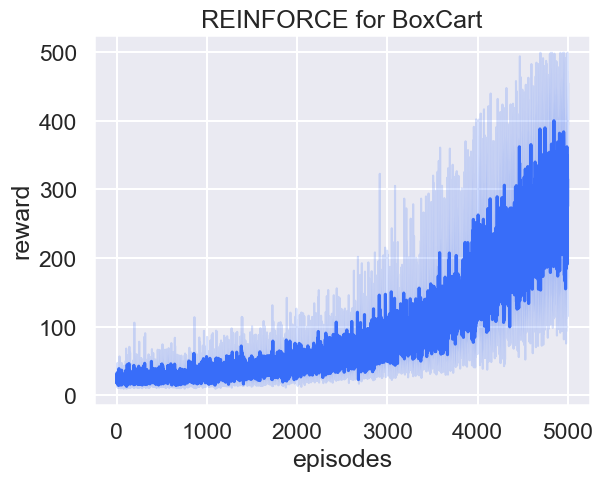

In [9]:
df1 = pd.DataFrame(rewards_over_seeds).melt()
df1.rename(columns={"variable": "episodes", "value": "reward"}, inplace=True)
sns.set(style="darkgrid", context="talk", palette="rainbow")
sns.lineplot(x="episodes", y="reward", data=df1).set(
    title="REINFORCE for BoxCart"
)
plt.show()